# Linear Regression Playground

This notebook serves as an interactive environment to train, evaluate, and visualize our cluster-based Linear Regression model. UUnlike the automated production scripts, this playground breaks down the pipeline into step-by-step modular blocks, allowing for testing of the modular functions implemented in `src/models/linear_regression.py`.

### Key Architecture
- **Granularity**: 15-minute intervals.
- **Strategy**: One Linear Regression model per cluster (Shape/Profile based).
- **Target**: Consumption in kW.
- **Evaluation**: Business-oriented metrics (MAPE, WMAPE) aggregated at the portfolio level.

## 0. Environment Setup

First, we ensure our environment can resolve project-level modules from the `src` directory.

In [1]:
import sys
import os
import pandas as pd
import numpy as np

# Ensure project root is in path to import modular tools
PROJECT_ROOT = os.path.abspath('..')
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

# Import specialized functions from our core library
from src.models.linear_regression import (
    load_processed_data, 
    preprocess_and_split, 
    train_models, 
    predict_models, 
    evaluate_models,
    save_cluster_artifacts
)
from src.tools.visualization import plot_cluster_portfolio, analyze_time_periods

print("Setup complete. project modules loaded.")

Setup complete. project modules loaded.


## 1. Data Loading

We load the parquet file generated by the preprocessing pipeline. This file contains all features, including lags, rolling windows, weather signals, and cluster assignments.

In [2]:
dataset_path = os.path.join(PROJECT_ROOT, 'Datasets', 'processed_electricity_data.parquet')
df_long = load_processed_data(dataset_path)

print(f"\nLoaded {len(df_long):,} observations.")
df_long[['ClientID', 'Date', 'Consumption', 'Cluster', 'Consumer_Category']].head()

Loading processed data...

Loaded 41,548,234 observations.


,ClientID,Date,Consumption,Cluster,Consumer_Category
0,MT_001,2012-01-08 00:15:00,5.076142,1.0,Light
1,MT_001,2012-01-08 00:30:00,5.076142,1.0,Light
2,MT_001,2012-01-08 00:45:00,5.076142,1.0,Light
3,MT_001,2012-01-08 01:00:00,5.076142,1.0,Light
4,MT_001,2012-01-08 01:15:00,3.807106,1.0,Light


## Step 2. Feature Engineering & Data Splitting

This step performs several critical actions:
1. **Train/Test Split**: Uses data before 2014 for training and 2014 onwards for testing.
2. **Standardization**: 
   - Weather signals (HDH, CDH) are scaled globally.
   - Consumption is scaled **per client** using individual StandardScalers to handle different orders of magnitude between consumers.

In [3]:
results = preprocess_and_split(df_long)

# Unpacking results for clarity
train_df, test_df, X_train, y_train, X_test, client_scalers, scaler_weather, feature_cols = results

print(f"\nFeature Engineering Complete.")
print(f"Training set rows: {len(X_train):,}")
print(f"Testing set rows:  {len(X_test):,}")

Feature Engineering and Train/Test Split...


Scaling Clients:  31%|███       | 114/369 [00:09<00:10, 25.27it/s]

Scaling Clients:  33%|███▎      | 122/369 [00:09<00:08, 30.52it/s]

Scaling Clients:  37%|███▋      | 135/369 [00:10<00:15, 14.97it/s]

Scaling Clients:  44%|████▍     | 162/369 [00:13<00:17, 11.87it/s]

Scaling Clients:  49%|████▉     | 181/369 [00:15<00:14, 12.93it/s]

Scaling Clients:  91%|█████████▏| 337/369 [00:31<00:02, 11.84it/s]

Scaling Clients: 100%|██████████| 369/369 [00:34<00:00, 10.62it/s]


Training shape: (28694604, 53)
Testing shape:  (12853630, 53)

Feature Engineering Complete.
Training set rows: 28,694,604
Testing set rows:  12,853,630


## 3. Cluster-based Model Training

Instead of training one global model, we train one independent Linear Regression for each identified cluster (Shape Profiles). This allows the model to learn specific behaviors for residential vs. industrial consumers.

In [4]:
cluster_models = train_models(X_train, y_train, train_df)

print(f"\n Successfully trained {len(cluster_models)} cluster models.")

Training Linear Regression models per cluster...
 - Model for Cluster 0 trained on 1677192 historical rows.
 - Model for Cluster 1 trained on 5283783 historical rows.
 - Model for Cluster 2 trained on 4120059 historical rows.
 - Model for Cluster 3 trained on 1003525 historical rows.
 - Model for Cluster 4 trained on 16610045 historical rows.

 Successfully trained 5 cluster models.


## 4. Vectorized Day-Ahead Prediction

We apply the trained models to the test set. The prediction is vectorized per cluster for high performance. We also apply physical constraints (capping consumption at 0 kW).

In [5]:
test_df = predict_models(cluster_models, test_df, X_test, client_scalers)

print("\nPredictions generated for the entire test horizon.")
test_df[['ClientID', 'Date', 'Predicted_Consumption_Scaled']].head()

Predicting on Test Set (Vectorized Day-Ahead)...
Applying physical constraints (Capping at 0 kW)...
Predictions Complete!

Predictions generated for the entire test horizon.


,ClientID,Date,Predicted_Consumption_Scaled
69503,MT_001,2014-01-01 00:00:00,-0.542430
69504,MT_001,2014-01-01 00:15:00,-0.542421
69505,MT_001,2014-01-01 00:30:00,-0.520148
69506,MT_001,2014-01-01 00:45:00,-0.542403
69507,MT_001,2014-01-01 01:00:00,-0.658159


## 5. Performance Evaluation

We inverse-transform the predictions back to the original kW scale and calculate error metrics. 
- **MAPE** (Mean Absolute Percentage Error): Sensitivity to percentage deviations.
- **WMAPE** (Weighted MAPE): Weighting errors by volume, crucial for business reporting.

In [6]:
cluster_eval, summary = evaluate_models(test_df, client_scalers)
print("\nEvaluation Summary Table:")
display(summary)


Evaluating model (raw kW)...

--- LINEAR REGRESSION PERFORMANCE BY CLUSTER (BUSINESS ORIENTED) ---

         Portfolio_MAPE  Portfolio_WMAPE
Cluster                                 
0.0               30.45             3.90
1.0               46.68             4.27
2.0              148.18             6.90
3.0               13.17            11.12
4.0                5.32             3.10

Global Portfolio MAPE:  48.76%
Global Portfolio WMAPE: 5.31%

Evaluation Summary Table:


,Portfolio_MAPE,Portfolio_WMAPE
Cluster,,
0.0,30.45,3.90
1.0,46.68,4.27
2.0,148.18,6.90
3.0,13.17,11.12
4.0,5.32,3.10


## 6. Visual Analytics

We visualize the aggregated portfolio load (Actual vs. Predicted) and analyze the error distribution across different time windows.

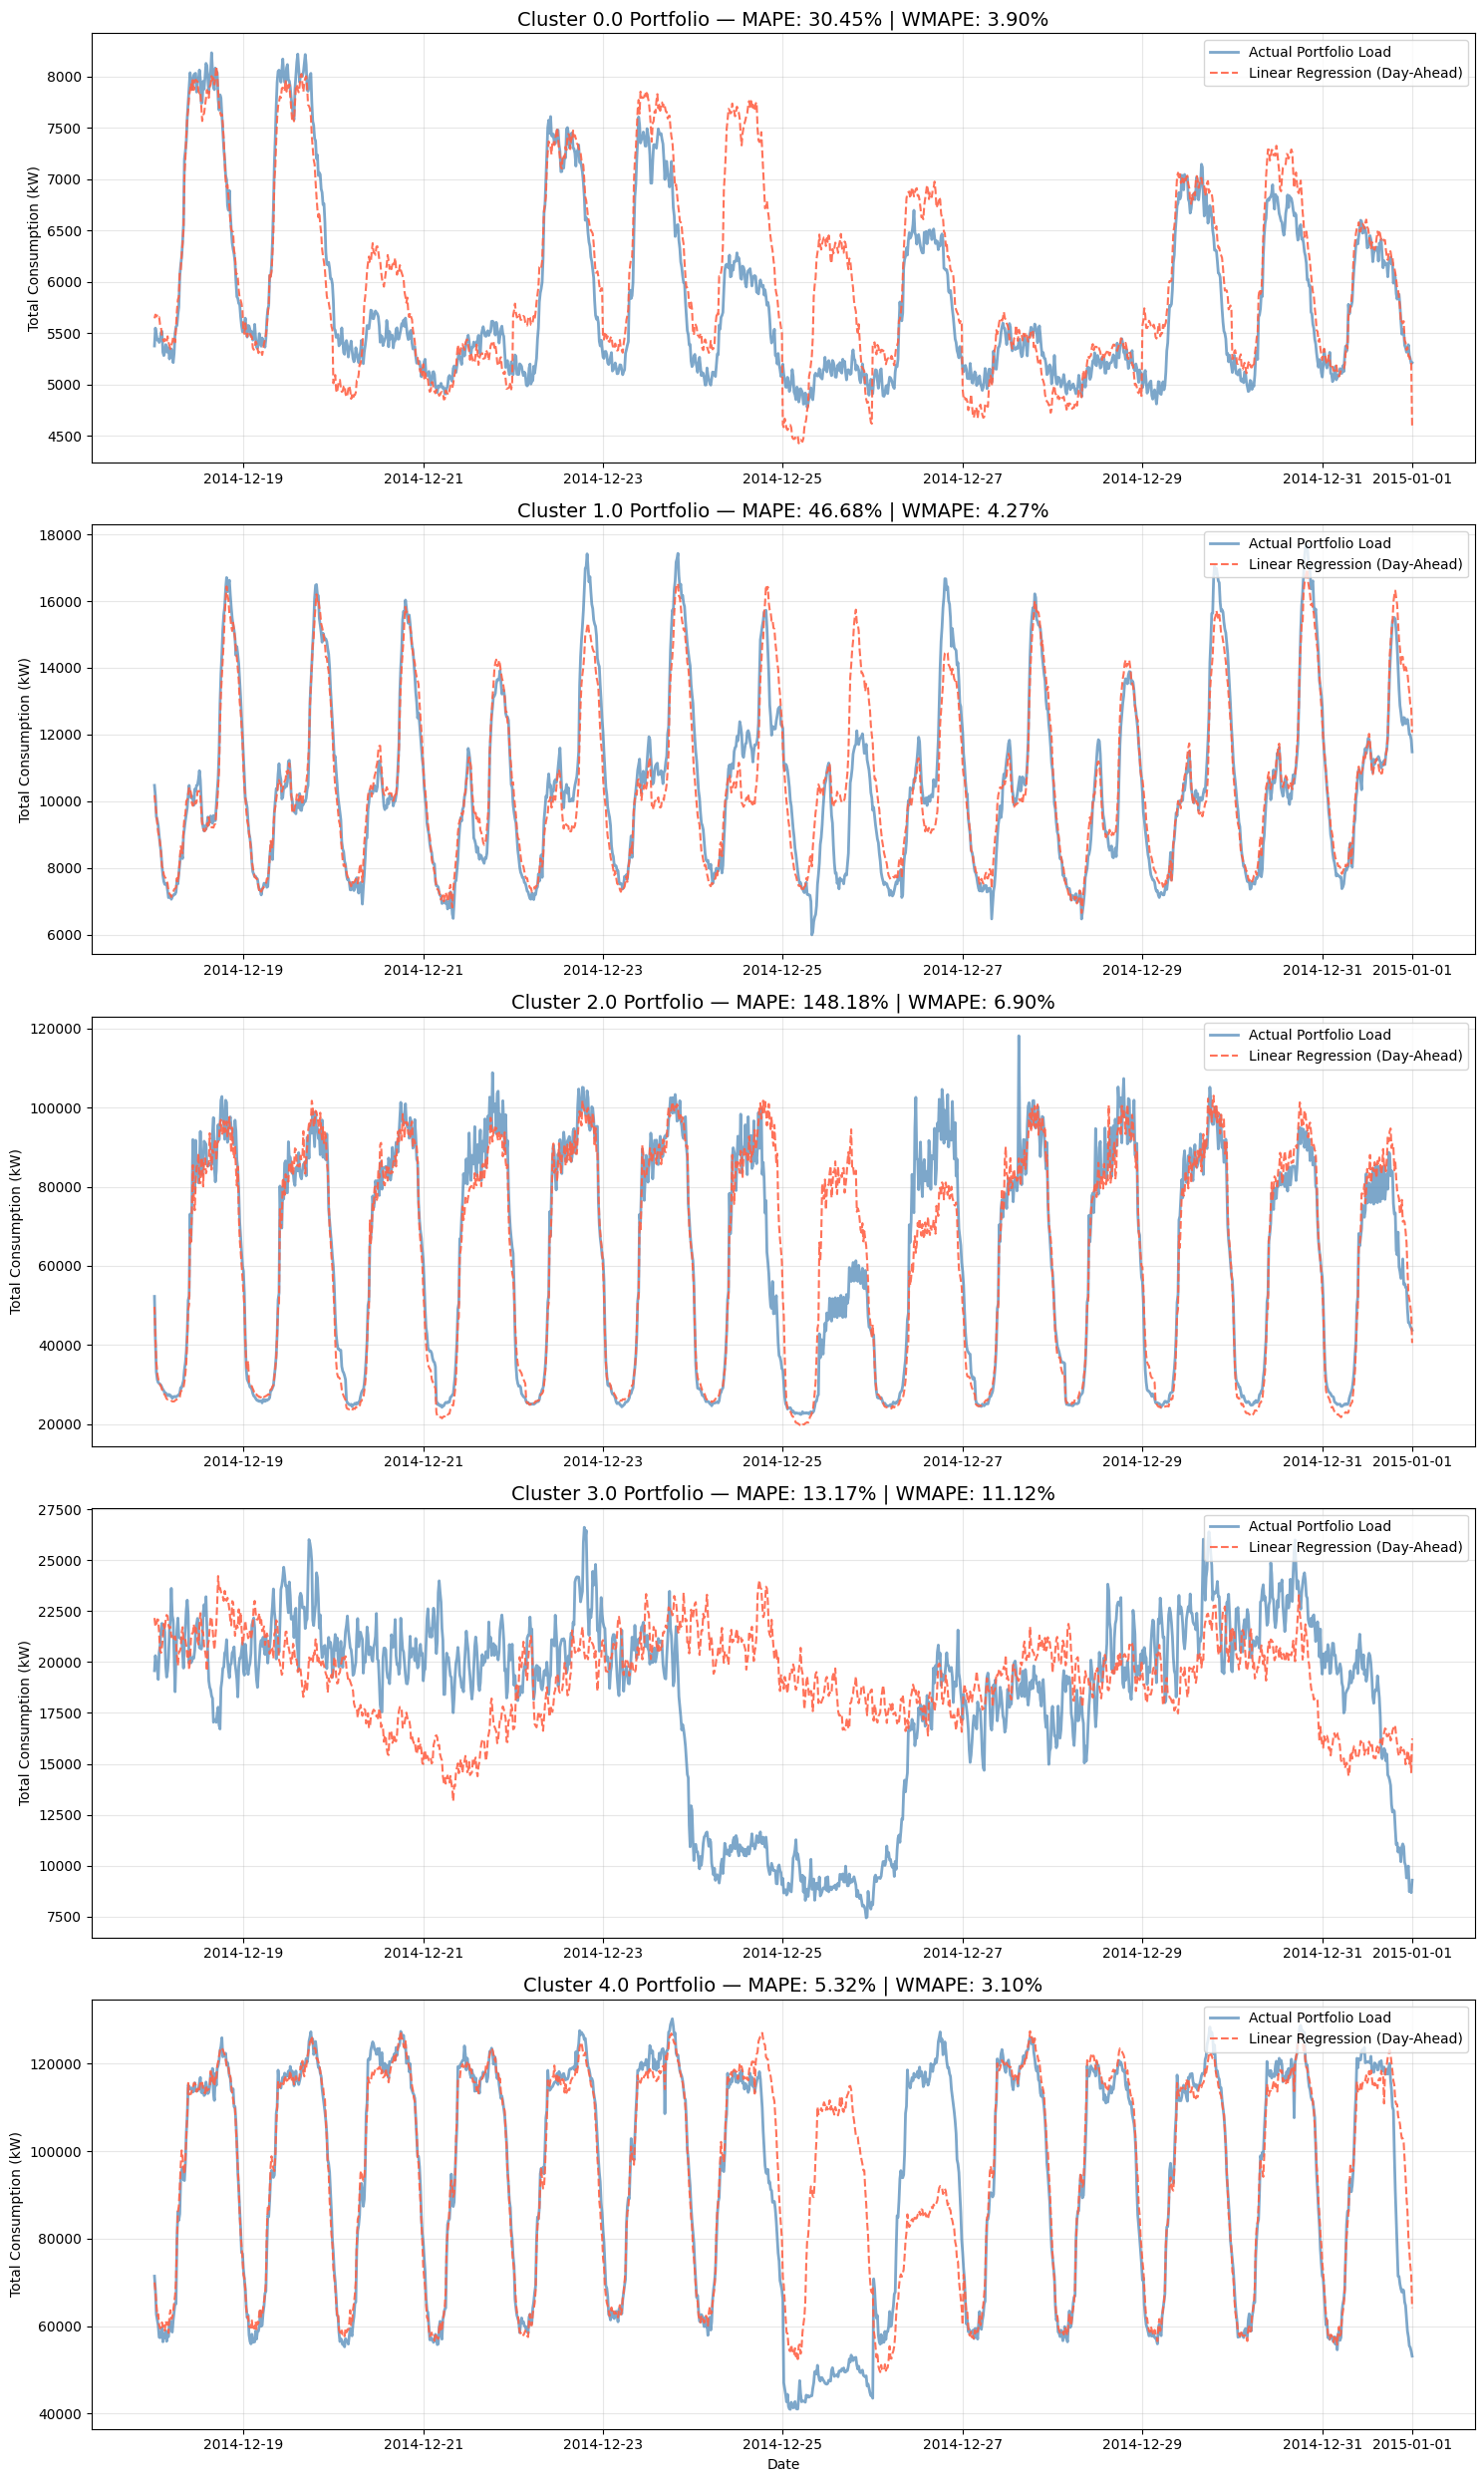

In [7]:
# Plot the last 2 weeks (1344 steps) of the portfolio
plot_cluster_portfolio(cluster_eval, summary, model_label="Linear Regression")


--- PORTFOLIO PERFORMANCE BY TIME PERIOD (Aggregated) ---
  Dec 31 to Apr 02:   WMAPE = 3.82% | MAPE = 17.08%
  Apr 02 to Jul 02:   WMAPE = 3.87% | MAPE = 3.78%
  Jul 02 to Oct 01:   WMAPE = 3.27% | MAPE = 3.20%
  Oct 01 to Jan 01:   WMAPE = 4.11% | MAPE = 4.44%


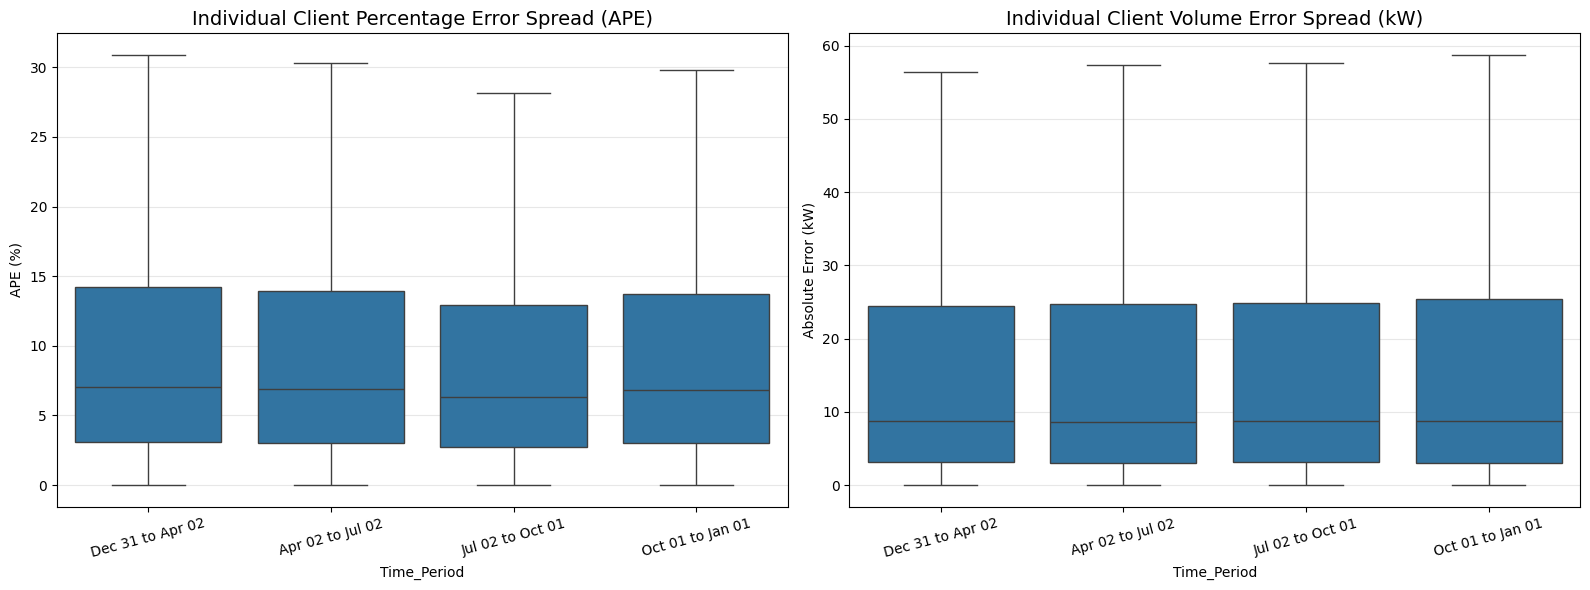

In [8]:
# Perform time-period split analysis
analyze_time_periods(test_df)

## 7. Persisting Artifacts

Finally, we save the models and scalers so they can be used by the **Agent Chatbot** for live forecasting.

In [9]:
client_clusters = df_long.drop_duplicates(subset=['ClientID']).set_index('ClientID')['Cluster'].to_dict()
save_path = os.path.join(PROJECT_ROOT, 'agent', 'artifacts')

save_cluster_artifacts(
    cluster_models, 
    client_scalers, 
    scaler_weather, 
    feature_cols, 
    client_clusters, 
    artifacts_dir=save_path
)

print("All production artifacts saved to agent/artifacts/")

Saving Cluster Linear Regression artifacts to /Users/federicogiorgi/Library/CloudStorage/OneDrive-Personal/Documenti/GitHub/forecasting-electricity/agent/artifacts...
Successfully saved /Users/federicogiorgi/Library/CloudStorage/OneDrive-Personal/Documenti/GitHub/forecasting-electricity/agent/artifacts/lr_cluster_models.pkl
All production artifacts saved to agent/artifacts/
